In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

In [ ]:
import pandas as pd

df = pd.read_csv(path + "/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
data =df.drop(['Time'], axis=1)
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
from matplotlib import rcParams

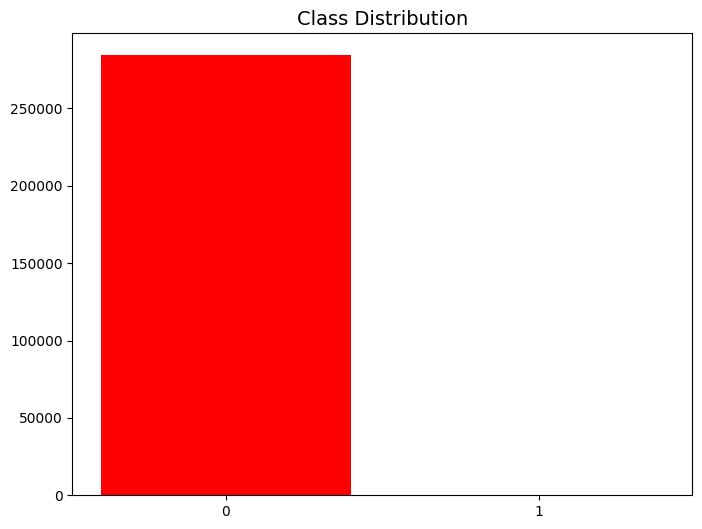

In [ ]:
rcParams['figure.figsize'] = 8, 6
plt.bar(data['Class'].unique(), data['Class'].value_counts(), color=['red', 'green'])
plt.xticks([0, 1])
plt.title("Class Distribution", fontsize=14)
plt.show()

In [ ]:
x = data.drop('Class', axis=1)
y = data['Class']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
Hp_params = {'criterion':['gini', 'entropy'], 'max_depth':[1,2,3,4,5]}
tree_GS_param = GridSearchCV(DecisionTreeClassifier(),  Hp_params, cv=5, scoring='roc_auc',n_jobs=-1, verbose=1)
tree_GS_param.fit(x_train, y_train)
print("The best parameters combined is ------")
print(tree_GS_param.best_params_)
print("The best score is ------")
print(tree_GS_param.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
The best parameters combined is ------
{'criterion': 'entropy', 'max_depth': 3}
The best score is ------
0.9376006650001395


In [ ]:
y_pred = tree_GS_param.predict(x_test)

In [ ]:
cm1 = confusion_matrix(y_test, y_pred)
print(cm1)
print(classification_report(y_test, y_pred, target_names=["Safe", "Fraud"]))

#Calculate sensitivity and specificity

total1=sum(sum(cm1))
accuracy1=(cm1[0,0]+cm1[1,1])/total1
print ('Accuracy : ', accuracy1)

sensitivity1 = cm1[0,0]/(cm1[0,0]+cm1[0,1])
print('Sensitivity : ', sensitivity1 )

specificity1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])
print('Specificity : ', specificity1)

[[56852    12]
 [   21    77]]
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00     56864
       Fraud       0.87      0.79      0.82        98

    accuracy                           1.00     56962
   macro avg       0.93      0.89      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy :  0.999420666409185
Sensitivity :  0.9997889701744513
Specificity :  0.7857142857142857


In [ ]:
pip install graphviz

In [ ]:
from sklearn.tree import export_graphviz
from sklearn import tree
import graphviz
import pydotplus
from IPython.display import Image

AttributeError: 'GridSearchCV' object has no attribute 'tree_'

In [ ]:
from sklearn.ensemble import BaggingClassifier
hp_bagging = {'n_estimators':[3,4,5,6]}
Tree_Gridsearch_paramters=GridSearchCV(BaggingClassifier(),hp_bagging,scoring='roc_auc',n_jobs=-1,cv=5,verbose=2)
tree_bagg = Tree_Gridsearch_paramters.fit(x_train, y_train)


#Print the best hyper paramters combination for the best model
print ("The best paramter combination is ")
print(tree_bagg.best_params_)  #gets best estimator
Final_Model=tree_bagg.best_estimator_ #gets best estimator
print("The best AUC score was ")
print(tree_bagg.best_score_)  #gets best score for best estimator # -0.83828599184062269


Fitting 5 folds for each of 4 candidates, totalling 20 fits


In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
Hyper_paramters_RF={'criterion':['gini','entropy'],'max_depth':[4,10],'n_estimators':[50, 100], 'max_features':['sqrt'] }



Tree_Gridsearch_paramters=GridSearchCV(BaggingClassifier(),hp_bagging,scoring='roc_auc',n_jobs=-1,cv=5,verbose=2)
tree_bagg = Tree_Gridsearch_paramters.fit(x_train, y_train)


#Print the best hyper paramters combination for the best model
print ("The best paramter combination is ")
print(tree_bagg.best_params_)  #gets best estimator
Final_Model=tree_bagg.best_estimator_ #gets best estimator
print("The best AUC score was ")
print(tree_bagg.best_score_)  #gets best score for best estimator # -0.83828599184062269
